In [1]:
from google.colab import files
uploaded = files.upload()

Saving student_data.csv to student_data.csv


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv("student_data.csv")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [11]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.mean(numeric_only=True)

,0
age,16.696203
Medu,2.749367
Fedu,2.521519
traveltime,1.448101
studytime,2.035443
failures,0.334177
famrel,3.944304
freetime,3.235443
goout,3.108861
Dalc,1.481013


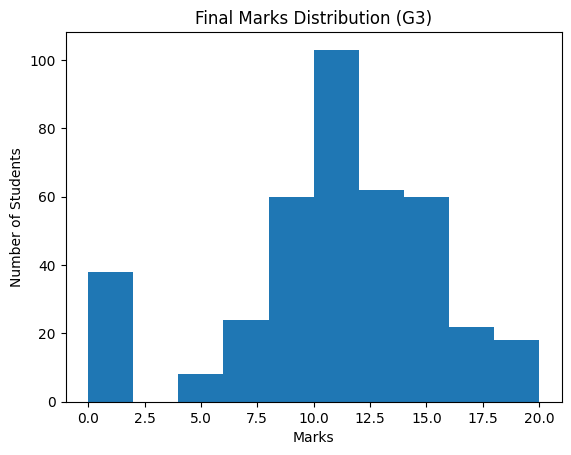

In [14]:
plt.hist(df['G3'])
plt.title("Final Marks Distribution (G3)")
plt.xlabel("Marks")
plt.ylabel("Number of Students")
plt.show()

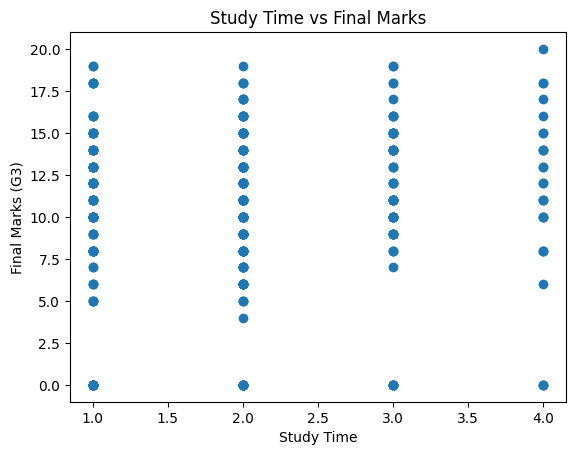

In [15]:
plt.scatter(df['studytime'], df['G3'])
plt.xlabel("Study Time")
plt.ylabel("Final Marks (G3)")
plt.title("Study Time vs Final Marks")
plt.show()

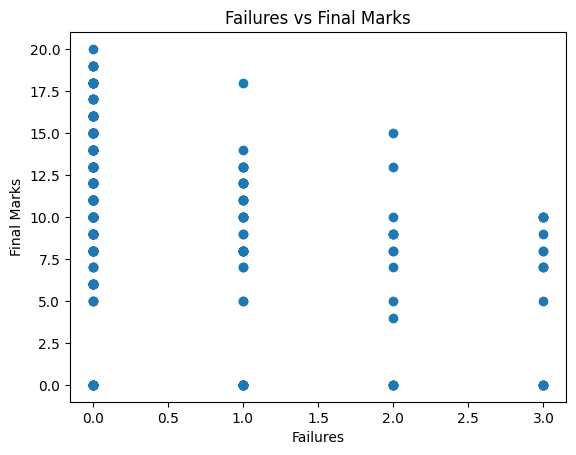

In [16]:
plt.scatter(df['failures'], df['G3'])
plt.xlabel("Failures")
plt.ylabel("Final Marks")
plt.title("Failures vs Final Marks")
plt.show()

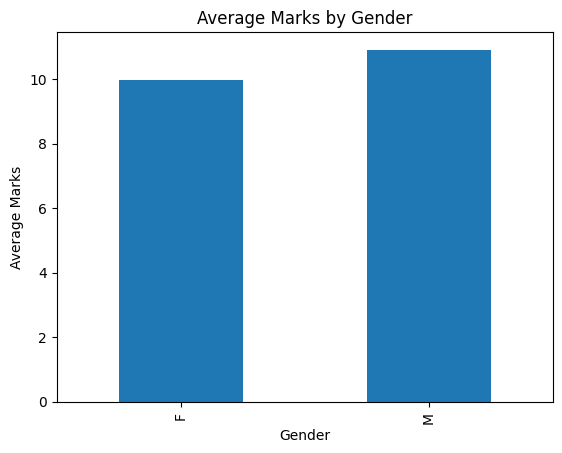

In [17]:
df.groupby('sex')['G3'].mean().plot(kind='bar')
plt.title("Average Marks by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Marks")
plt.show()

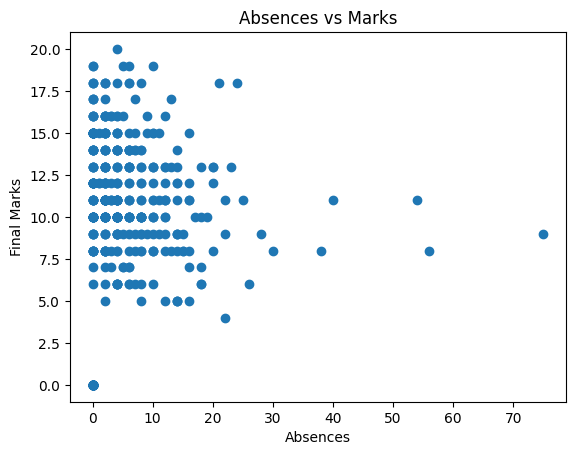

In [18]:
plt.scatter(df['absences'], df['G3'])
plt.xlabel("Absences")
plt.ylabel("Final Marks")
plt.title("Absences vs Marks")
plt.show()

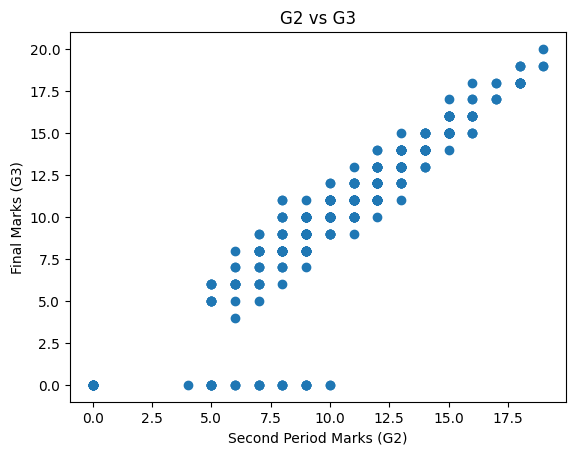

In [19]:
plt.scatter(df['G2'], df['G3'])
plt.xlabel("Second Period Marks (G2)")
plt.ylabel("Final Marks (G3)")
plt.title("G2 vs G3")
plt.show()

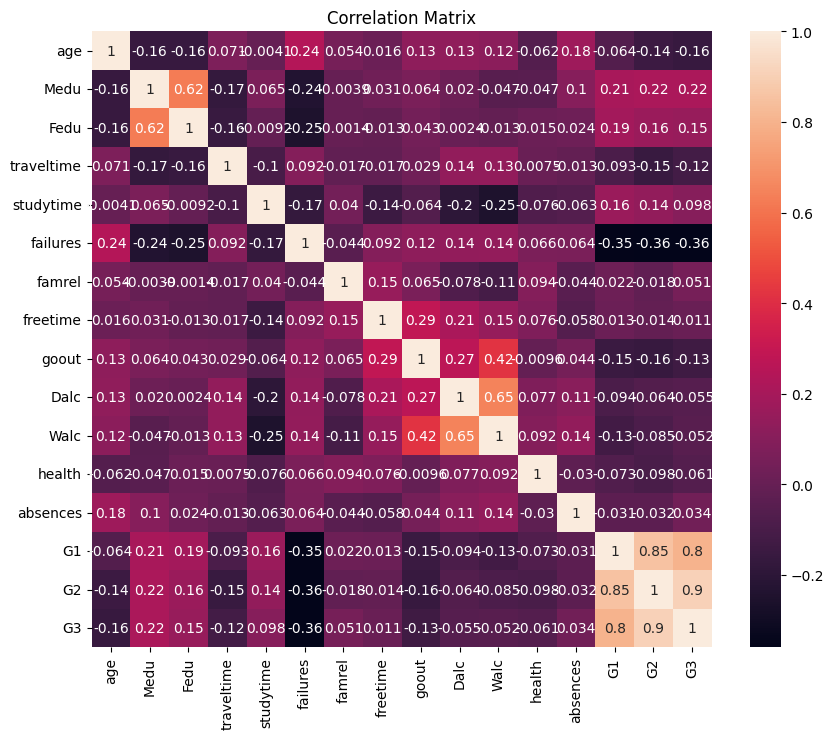

In [20]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

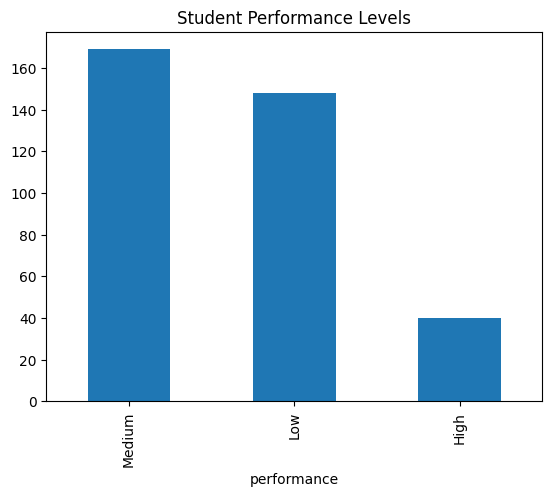

In [21]:
df['performance'] = pd.cut(df['G3'],
                          bins=[0,10,15,20],
                          labels=['Low','Medium','High'])

df['performance'].value_counts().plot(kind='bar')
plt.title("Student Performance Levels")
plt.show()